In [1]:
import pymc as pm, polars as pl, arviz as az, numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import legend

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [2]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/Trolley.csv", separator=";").select(
    "response", "id", "age", "male", "edu", "action", "intention", "contact"
)

# define categorical and enum types
ordered_education_categories = ["Elementary School",
                                "Middle School",
                                "Some High School",
                                "High School Graduate",
                                "Some College",
                                "Bachelor's Degree",
                                "Master's Degree",
                                "Graduate Degree"]

df = df.with_columns(
    education=pl.col("edu").cast(pl.Enum(ordered_education_categories)),
    id=pl.col("id").cast(pl.Categorical)
)
df = standardize_columns(df, ["age"])

In [11]:
df.filter(pl.col("male") == 1).group_by("education").len()

education,len
enum,u32
"""High School Graduate""",420
"""Some College""",1260
"""Elementary School""",60
"""Graduate Degree""",570
"""Bachelor's Degree""",2100
"""Some High School""",270
"""Middle School""",90
"""Master's Degree""",930


In [12]:
df.filter(pl.col("male") == 0).group_by("education").len()

education,len
enum,u32
"""Some High School""",150
"""Master's Degree""",480
"""Graduate Degree""",480
"""Some College""",1200
"""High School Graduate""",450
"""Bachelor's Degree""",1440
"""Middle School""",30


In [3]:
# get priors for cumulative log odds for cutpoints
cutpoint_priors = df.group_by("response").len().sort("response").with_columns(
    cumulative_probs=pl.col("len").cum_sum() / len(df))
cutpoint_priors = cutpoint_priors.with_columns(
    cumulative_log_odds=(pl.col("cumulative_probs") / (1 - pl.col("cumulative_probs"))).log())
cutpoint_priors

response,len,cumulative_probs,cumulative_log_odds
i64,u32,f64,f64
1,1274,0.128298,-1.916091
2,909,0.219839,-1.266606
3,1071,0.327694,-0.718634
4,2323,0.561631,0.247786
5,1462,0.708862,0.889864
6,1445,0.854381,1.769381
7,1446,1.0,inf


In [4]:
with pm.Model(coords={
    "education": ordered_education_categories,
    "education_increments": ordered_education_categories[1:]
}) as m_ordered_logit_stable_wo_age:
    # define data
    education = pm.Data("education", df["education"].to_physical().to_numpy())

    # Sample increments for education levels ABOVE Elementary School
    # Dirichlet ensures they sum to 1 and are all positive
    alpha_dirichlet = 2.0 * np.ones(df['education'].n_unique() - 1)
    delta_increments = pm.Dirichlet("delta_increments", a=alpha_dirichlet, dims="education_increments")

    # Prepend 0 for Elementary School (baseline), then cumsum for cumulative effects
    delta_with_baseline = pm.math.concatenate([[0], delta_increments])
    delta = pm.Deterministic("delta", pm.math.cumsum(delta_with_baseline), dims="education")

    # Priors for linear model coefficients
    b_education = pm.Normal("b_education", 0, 1)

    # Linear model (phi) - represents the latent tendency
    phi = b_education * delta[education]
    # Cutpoints with tighter priors
    cutpoints = pm.Normal("cutpoints",
                          mu=cutpoint_priors["cumulative_log_odds"].to_numpy()[:-1],
                          sigma=0.5,
                          transform=pm.distributions.transforms.ordered)

    # Likelihood
    response_obs = pm.OrderedLogistic("response_obs",
                                      eta=phi,
                                      cutpoints=cutpoints,
                                      observed=df["response"].to_numpy() - 1)

    # Sample with better settings
    posterior_stable_wo_age = pm.sample(draws=1000, chains=4,
                                 tune=2000,
                                 target_accept=0.99,
                                 progressbar=True,
                                 random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [delta_increments, b_education, cutpoints]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 253 seconds.


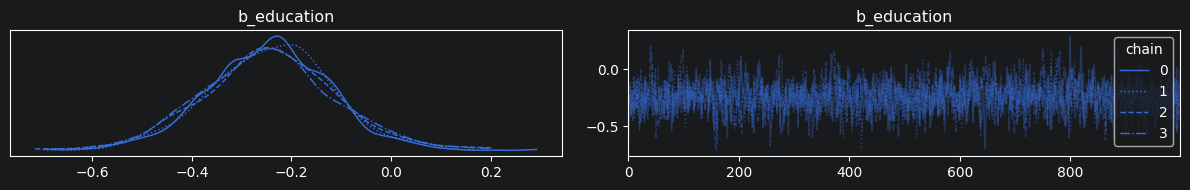

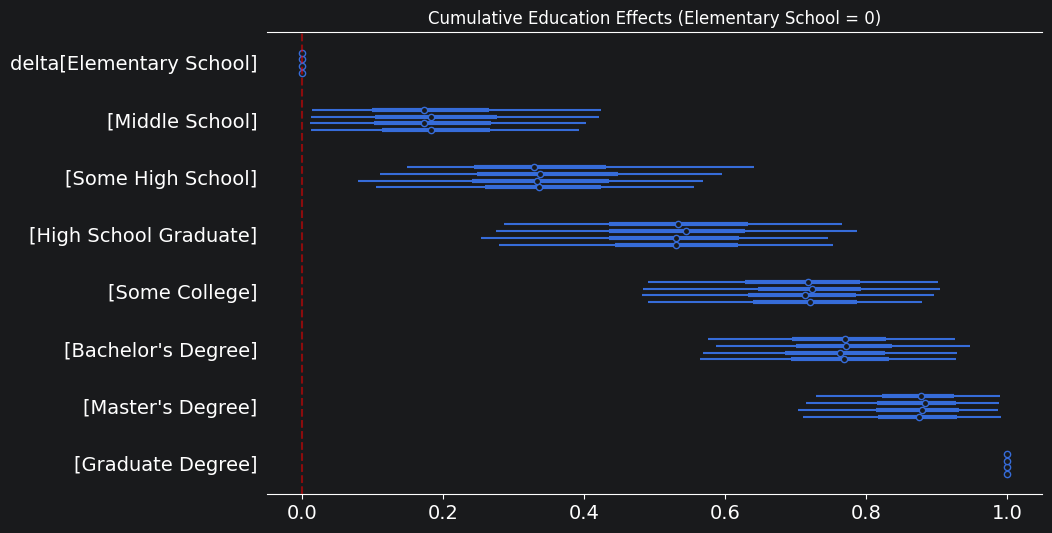

In [5]:
plot_trace(posterior_stable_wo_age, legend=True, var_names=["b_education"])

# Visualize the education effects (delta)
az.plot_forest(posterior_stable_wo_age, var_names=["delta"], figsize=(10, 6))
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.title("Cumulative Education Effects (Elementary School = 0)")
plt.show()

In [6]:
with pm.Model(coords={
    "education": ordered_education_categories,
    "education_increments": ordered_education_categories[1:]
}) as m_ordered_logit_stable:
    # define data
    education = pm.Data("education", df["education"].to_physical().to_numpy())
    age = pm.Data("age", df["age"].to_numpy())

    # Sample increments for education levels ABOVE Elementary School
    # Dirichlet ensures they sum to 1 and are all positive
    alpha_dirichlet = 2.0 * np.ones(df['education'].n_unique() - 1)
    delta_increments = pm.Dirichlet("delta_increments", a=alpha_dirichlet, dims="education_increments")
    
    # Prepend 0 for Elementary School (baseline), then cumsum for cumulative effects
    delta_with_baseline = pm.math.concatenate([[0], delta_increments])
    delta = pm.Deterministic("delta", pm.math.cumsum(delta_with_baseline), dims="education")

    # Priors for linear model coefficients
    b_education = pm.Normal("b_education", 0, 1)
    b_age = pm.Normal("b_age", 0, 0.5)

    # Linear model (phi) - represents the latent tendency
    phi = b_education * delta[education] + b_age * age

    # Cutpoints with tighter priors
    cutpoints = pm.Normal("cutpoints",
                          mu=cutpoint_priors["cumulative_log_odds"].to_numpy()[:-1],
                          sigma=0.5,
                          transform=pm.distributions.transforms.ordered)

    # Likelihood
    response_obs = pm.OrderedLogistic("response_obs",
                                      eta=phi,
                                      cutpoints=cutpoints,
                                      observed=df["response"].to_numpy() - 1)

    # Sample with better settings
    posterior_stable = pm.sample(draws=1000, chains=4, 
                                 tune=2000,
                                 target_accept=0.99,
                                 progressbar=True,
                                 random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [delta_increments, b_education, b_age, cutpoints]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 245 seconds.


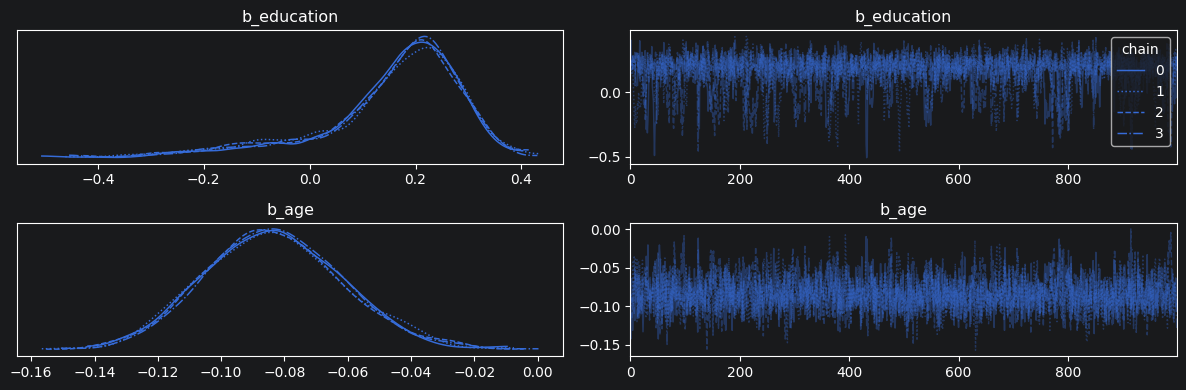

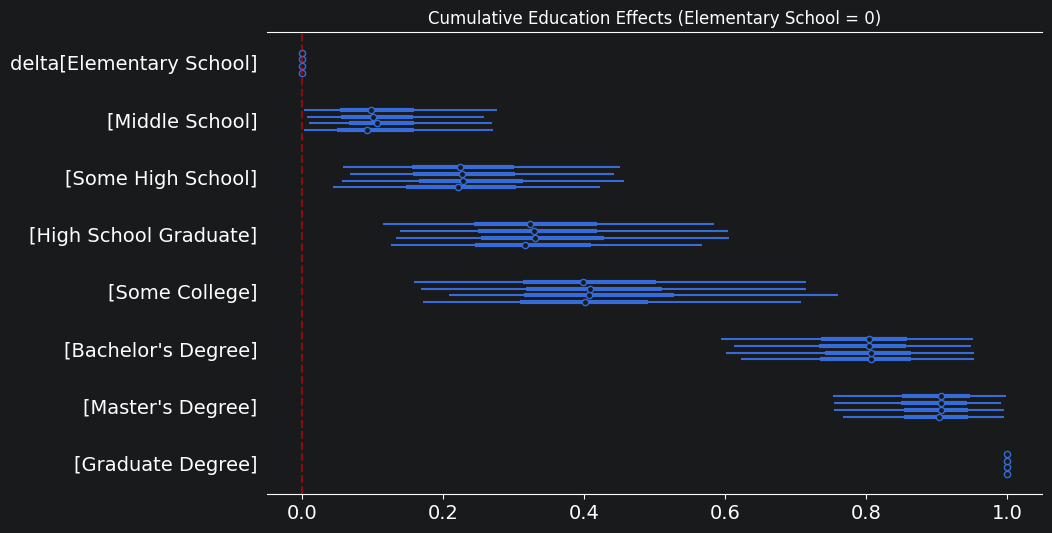

In [7]:
plot_trace(posterior_stable, legend=True, var_names=["b_education", "b_age"])

# Visualize the education effects (delta)
az.plot_forest(posterior_stable, var_names=["delta"], figsize=(10, 6))
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.title("Cumulative Education Effects (Elementary School = 0)")
plt.show()